=== Decision Tree Report ===
              precision    recall  f1-score   support

          No       0.81      0.83      0.82       161
         Yes       0.79      0.76      0.78       136

    accuracy                           0.80       297
   macro avg       0.80      0.80      0.80       297
weighted avg       0.80      0.80      0.80       297



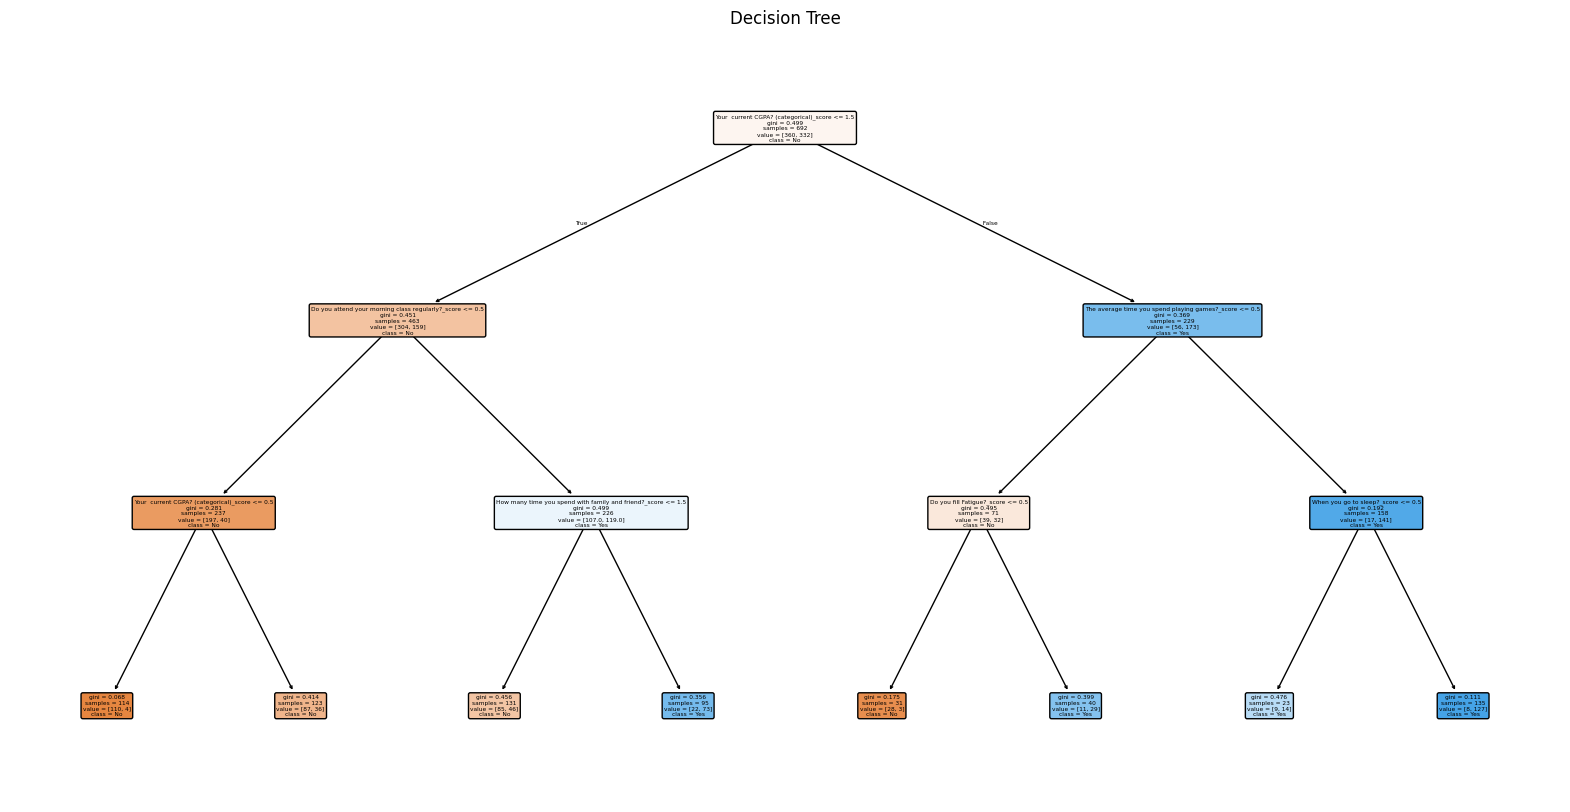

=== Logistic Regression Report ===
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       161
         Yes       1.00      1.00      1.00       136

    accuracy                           1.00       297
   macro avg       1.00      1.00      1.00       297
weighted avg       1.00      1.00      1.00       297

Logistic Regression Feature Coefficients:
Your  current CGPA? (categorical)_score: 4.0664
When you go to sleep?_score: 3.7812
Do you attend your morning class regularly?_score: 3.9177
The average time you spend playing games?_score: 3.8767
How many time you spend with family and friend?_score: 3.9789
Do you fill Fatigue?_score: 3.7553

Decision Tree Feature Importances:
Your  current CGPA? (categorical)_score: 0.4104
When you go to sleep?_score: 0.0297
Do you attend your morning class regularly?_score: 0.2030
The average time you spend playing games?_score: 0.1310
How many time you spend with family and friend?_score: 0.1314
Do yo

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("preprocessed_unigame time.csv.xlsx")
df.columns = [col.strip() for col in df.columns]  # Clean column names

# Define columns
question_cols = {
    "Your  current CGPA? (categorical)": {"Low": 0, "Average": 1, "High": 2},
    "When you go to sleep?": {"Healthy": 0, "Average": 1, "Late": 2, "Very Late": 3},
    "Do you attend your morning class regularly?": {"Yes": 0, "No": 1},
    "The average time you spend playing games?": {"Low": 0, "Moderate": 1, "High": 2},
    "How many time you spend with family and friend?": {"Low": 2, "Moderate": 1, "High": 0},
    "Do you fill Fatigue?": {"Yes": 1, "No": 0}
}

# Apply scores
for col, mapping in question_cols.items():
    df[col + "_score"] = df[col].map(mapping)

# Feature set
score_cols = [col + "_score" for col in question_cols]
df["Total_score"] = df[score_cols].sum(axis=1)

# Classification rule
df["Classification"] = df["Total_score"].apply(lambda x: "Yes" if x >= 6 else "No")

# Prepare features and labels
X = df[score_cols].dropna()
y = df.loc[X.index, "Classification"]

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# --- Decision Tree ---
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)
tree_preds = tree_clf.predict(X_test)
print("=== Decision Tree Report ===")
print(classification_report(y_test, tree_preds, target_names=label_encoder.classes_))

# Plot decision tree
plt.figure(figsize=(20, 10))
plot_tree(tree_clf, feature_names=X.columns, class_names=label_encoder.classes_,
          filled=True, rounded=True)
plt.title("Decision Tree")
plt.show()

# --- Logistic Regression ---
logit_clf = LogisticRegression()
logit_clf.fit(X_train, y_train)
logit_preds = logit_clf.predict(X_test)
print("=== Logistic Regression Report ===")
print(classification_report(y_test, logit_preds, target_names=label_encoder.classes_))

# Show logistic regression coefficients
print("Logistic Regression Feature Coefficients:")
for name, coef in zip(X.columns, logit_clf.coef_[0]):
    print(f"{name}: {coef:.4f}")

# Show decision tree feature importances
print("\nDecision Tree Feature Importances:")
for name, imp in zip(X.columns, tree_clf.feature_importances_):
    print(f"{name}: {imp:.4f}")
